### 릿지(Ridge)
- 최소제곱 적합식의 수축 패널티라 불리는 항에 L2 패널티를 추가한것

- parameter
    - alpha 
        - 기본값 : 1.0
        - 규제의 강도 -> 클수록 회귀 계수가 작아지고 과대적합을 방지, 과소적합 위험 
    - solver
        - 기본값 : 'auto'
        - 데이터의 크기 / 희소성에 따라 적합한 solver를 선택 
        - 'cholesky' : 콜레스키 분해, 가장 기본적인 수식, 데이터의 개수가 작거나 중간 정도 
        - 'svd' : 특이값 분해, 다중공선성이 있는 경우에 조금 더 안정적으로 계산, 데이터의 개수가 작거나 중간 정도
        - 'sparse_cg', 'lspr' : 공액 기울기법(0인 데이터를 무시하고 계산), 대규모 데이터중 희소 데이터 
        - 'sag' : 확률적 평균 검사( 기존의 기울기만이 아니라 과거의 기울기의 평균을 이용하여 가중치 변화 ), 데이터의 행의 개수가 열의 개수보다 월등히 많은 경우 
        - 'saga' : sag 확장, 대규모 희소 데이터가 존재하는경우,  ElasticNet에서 사용
    - tol
        - 기본값 : 0.001 (1e-03)
        - 수렴의 판단 기준. 작을 수록 정밀. 속도면에서는 느려질수 있다. 
    - max_iter 
        - 기본값 : None
        - 최적화가 될때까지 최대 반복 횟수 
        - 데이터가 크거나 수치가 불안정한 경우에 필요
- 속성 
    - n_iter_
        - solver가 반복한 횟수를 입력 
    - coef_
        - 회귀 계수를 출력 (규제로 인한 가중치의 감소량때문에 선형회귀보다는 낮은 값들이 출력)

In [1]:
import pandas as pd 
import numpy as np 
from sklearn.datasets import load_diabetes
from sklearn.linear_model import Ridge
import matplotlib.pyplot as plt

In [2]:
# 데이터셋 로드 
diabetes = load_diabetes()

In [3]:
diabetes

{'data': array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
          0.01990749, -0.01764613],
        [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
         -0.06833155, -0.09220405],
        [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
          0.00286131, -0.02593034],
        ...,
        [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
         -0.04688253,  0.01549073],
        [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
          0.04452873, -0.02593034],
        [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
         -0.00422151,  0.00306441]], shape=(442, 10)),
 'target': array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
         69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
         68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
         87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
        259.,  53., 190., 142.,  75., 142.

In [4]:
diabetes.frame

In [5]:
df = pd.DataFrame(diabetes['data'], columns = diabetes['feature_names'])
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [6]:
# 알파 -> 규제의 강도 1e-03, 1e-02, 1e-01, 1e+00, 1e+01
# numpy에 logspace() 함수를 이용해서 데이터를 생성 
alphas = np.logspace(-3, 1, 5)
alphas

array([1.e-03, 1.e-02, 1.e-01, 1.e+00, 1.e+01])

In [7]:
# alpha 값에 따른 회귀 계수를 파악 
data = []

for a in alphas:
    # 모델 생성
    ridge = Ridge(alpha = a)
    # 모델에 학습 
    ridge.fit(diabetes['data'], diabetes['target'])
    # 학습이 된 모델에서 회귀계수를 data 빈 리스트에 추가 
    data.append(
        ridge.coef_
    )
data

[array([  -9.54916175, -239.08695779,  520.3693746 ,  323.82274522,
        -712.32215918,  413.37912498,   65.81132269,  167.51300694,
         720.9399241 ,   68.12336029]),
 array([  -7.19753448, -234.54976419,  520.58860098,  320.51713055,
        -380.6071353 ,  150.48467052,  -78.58927534,  130.31252148,
         592.34795865,   71.13484405]),
 array([   1.30870543, -207.19241786,  489.69517109,  301.76405786,
         -83.46603399,  -70.8268319 , -188.67889782,  115.7121356 ,
         443.81291747,   86.7493154 ]),
 array([  29.46611189,  -83.15427636,  306.35268015,  201.62773437,
           5.90961437,  -29.51549508, -152.04028006,  117.3117316 ,
         262.94429001,  111.87895644]),
 array([ 19.81284181,  -0.91842974,  75.41621398,  55.02515953,
         19.92462111,  13.94871542, -47.5538158 ,  48.2594332 ,
         70.14394833,  44.21389238])]

In [8]:
df_ridge = pd.DataFrame(
    data, index = alphas, columns = df.columns
)
df_ridge

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0.001,-9.549162,-239.086958,520.369375,323.822745,-712.322159,413.379125,65.811323,167.513007,720.939924,68.123360
0.010,-7.197534,-234.549764,520.588601,320.517131,-380.607135,150.484671,-78.589275,130.312521,592.347959,71.134844
0.100,1.308705,-207.192418,489.695171,301.764058,-83.466034,-70.826832,-188.678898,115.712136,443.812917,86.749315
1.000,29.466112,-83.154276,306.352680,201.627734,5.909614,-29.515495,-152.040280,117.311732,262.944290,111.878956
10.000,19.812842,-0.918430,75.416214,55.025160,19.924621,13.948715,-47.553816,48.259433,70.143948,44.213892


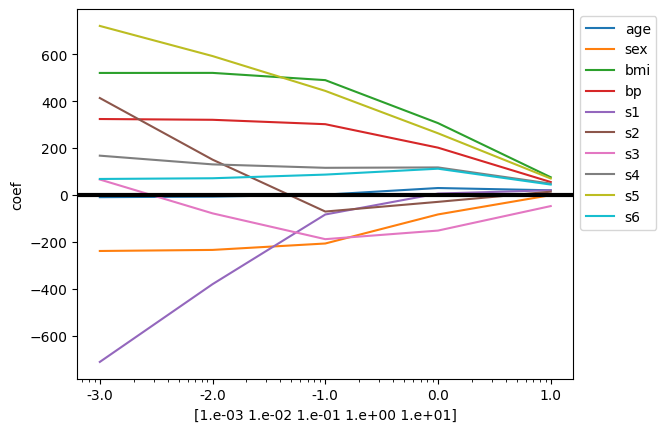

In [9]:
plt.semilogx(df_ridge)

plt.xticks(alphas, labels= np.log10(alphas))

plt.legend(labels = df_ridge.columns, bbox_to_anchor = (1, 1))
plt.xlabel(alphas)
plt.ylabel('coef')
plt.axhline(y = 0, color='black', linewidth = 3)

plt.show()

In [12]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(diabetes['data'], diabetes['target'])

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


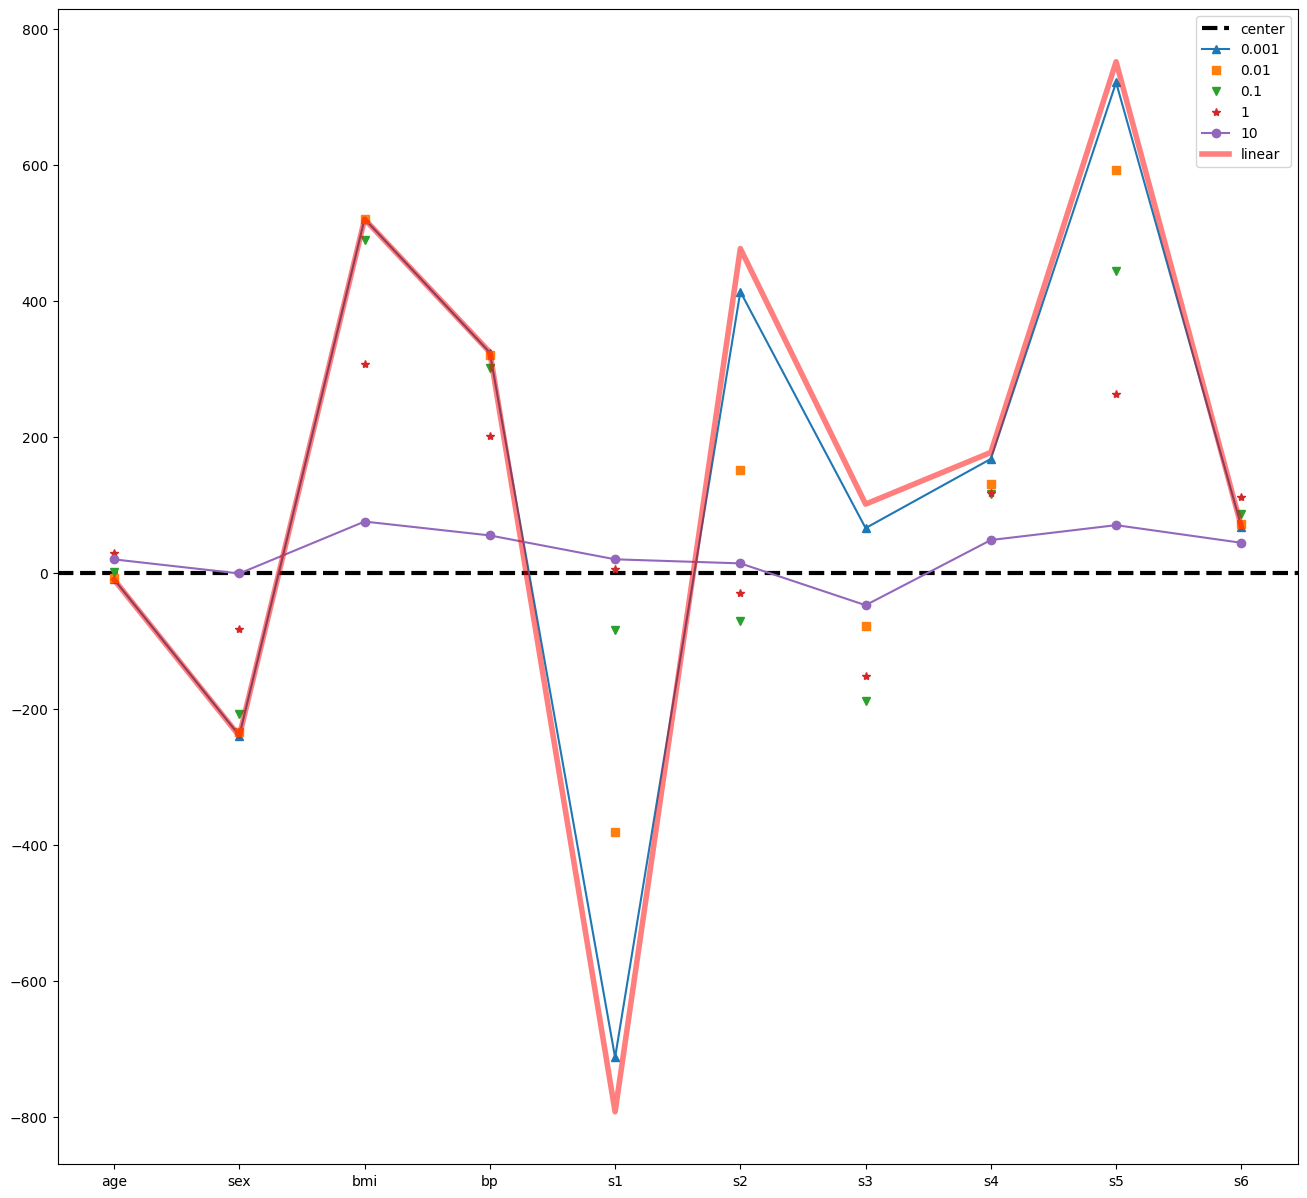

In [13]:
plt.figure(figsize=(16, 15))
plt.axhline(y= 0, linestyle='--', linewidth = 3, color='black')

plt.plot(df_ridge.loc[0.001, ], '^-')
plt.plot(df_ridge.loc[0.01, ], 's')
plt.plot(df_ridge.loc[0.1, ], 'v')
plt.plot(df_ridge.loc[1.0, ], '*')
plt.plot(df_ridge.loc[10.0, ], 'o-')
plt.plot(lr.coef_, 'r', linewidth = 4, alpha = 0.5)

plt.legend( ['center', 0.001, 0.01, 0.1, 1, 10, 'linear'], bbox_to_anchor = (1, 1) )

plt.show()

- 연습
    - 당뇨병 데이터를 이용하여 위험 지수를 예측 
    - train, test는 8:2 비율로 나눠주고 
    - 선형회귀의 방법으로 mae의 값을 이용하여 성능을 확인 
    - 릿지에서 알파 값을 0.01, 0.1, 1인 경우로 모델을 생성하고 학습 뒤 예측하고 mae의 값을 확인 
    - 가장 성능이 좋은 모델은 무엇인가?